# BCI (Barro Colorado Island) Visualization using AGB, Photogrammetry, Trail, and 3D Point Cloud Datasets

This tutorial demonstrates processing and visualization of Earth Observation (EO) data using Cloud-Optimized GeoTIFFs (COGs) and Cloud-Optimized Point Clouds (COPCs) with [Lonboard](https://developmentseed.org/lonboard/latest/). Lonboard supports interactive visualization of large raster and vector datasets, including COGs for imagery and gridded products, and COPCs/LAS-derived point cloud formats for LiDAR data.

In this tutorial, we use an Airborne LiDAR Scanning (ALS) point cloud over Barro Colorado Island (BCI), Panama, together with an Above-Ground Biomass (AGB) product, a trail dataset, and an RGB orthomosaic generated from photogrammetry. We created COGs for the raster products and use [TiTiler](https://developmentseed.org/titiler/) to dynamically serve map tiles for interactive visualization. The point cloud represents normalized canopy height values derived from the raw LiDAR observations.

Additional Resources:
1. [Lonboard](https://developmentseed.org/lonboard/latest/)
2. [TiTiler](https://developmentseed.org/titiler/)
3. [Converting LiDAR LAS Files to Cloud-Optimized Point Clouds (COPCs)](https://guide.cloudnativegeo.org/copc/lidar-las-to-copc.html)
4. [Introduction to Cloud-Optimized GeoTIFFs](https://guide.cloudnativegeo.org/cloud-optimized-geotiffs/intro.html)
5. [PDAL](https://pdal.io/en/2.6.0/about.html#what-is-pdal)

### Importing Packages

We import the required packages for this tutorial.

In [1]:
import geopandas as gpd
from lonboard import viz
import pdal
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lonboard import Map, BitmapLayer, BitmapTileLayer, PointCloudLayer, PolygonLayer
from lonboard.colormap import apply_continuous_cmap
import httpx
import json
from palettable.colorbrewer.sequential import YlGnBu_7, Greens_3
from palettable.colorbrewer.diverging import Spectral_9
from matplotlib.colors import Normalize
from lonboard import Map, PathLayer
from IPython.display import display
import ipywidgets as widgets

Next, we define the path to the ALS LiDAR file in COPC format to be visualized.

In [2]:
out_file = "norm_chunk.copc.laz"

### Reading the COPC file

We read the COPC file using the PDAL python package. Also, we sample the number of points by a factor of 50, thus reducing the number of points for visualization to save memory. PDAL processes point cloud data by executing pipelines comprising of various operations (separated by `|` below). For more details, the readers are recommended to follow [Converting LiDAR LAS Files to Cloud-Optimized Point Clouds (COPCs)](https://guide.cloudnativegeo.org/copc/lidar-las-to-copc.html).

In [3]:
pipeline = (pdal.Reader.copc(filename=out_file) | pdal.Filter.decimation(step=50) | pdal.Filter.stats())
pipeline.execute()

1425309

### Getting the Data Values

The data values from an executed pipeline are retrieved by calling the `arrays` method.

In [4]:
# Getting array values
arr_values = pipeline.arrays

### Creating Geo-dataframe

Now, we will create a data frame followed by a Geo-dataframe based on the data values. Lonboard requires the vector data as Geo-dataframe for visualization.

In [5]:
df = pd.DataFrame(arr_values[0])

In [6]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.X, df.Y, z=df.Z), crs="32617")

Also, Lonboard requires the Geo-dataframe to have its Spatial Reference System (SRS) as World Geodetic System 1984 (WGS 84). So, we re-project the geo-dataframe to `EPSG 4326`, which is the unique reference code for WGS 84.

In [7]:
gdf_proj = gdf.to_crs(4326)
gdf_proj.head()

,X,Y,Z,Intensity,ReturnNumber,NumberOfReturns,ScanDirectionFlag,EdgeOfFlightLine,Classification,Synthetic,...,Overlap,ScanAngleRank,UserData,PointSourceId,GpsTime,ScanChannel,TargetThick,DevRatio,Zref,geometry
0,626795.62,1012313.20,-0.11,6,3,3,0,0,2,0,...,0,-16.535999,1,13,3.691526e+08,0,0.048,1.0,141.56,POINT Z (-79.84599 9.1561 -0.11)
1,626781.55,1012329.30,5.46,26,3,3,0,0,1,0,...,0,-15.996000,1,13,3.691526e+08,0,0.320,1.4,148.22,POINT Z (-79.84611 9.15624 5.46)
2,626787.43,1012319.68,7.67,12,2,2,0,0,1,0,...,0,26.496000,1,15,3.691531e+08,0,0.120,1.0,150.16,POINT Z (-79.84606 9.15616 7.67)
3,626762.40,1012319.63,24.93,7,2,2,0,0,1,0,...,0,-18.294001,1,13,3.691526e+08,0,0.128,1.3,168.19,POINT Z (-79.84629 9.15616 24.93)
4,626754.43,1012318.80,9.21,18,2,4,0,0,1,0,...,0,-18.233999,3,13,3.691526e+08,0,0.184,1.1,152.84,POINT Z (-79.84636 9.15615 9.21)


In order to save memory, we delete the unrequired data frames. Also, we drop the columns which are not relevant for the visulization.

In [8]:
# Deleting not required dataframes
del(df)
del(gdf)

In [9]:
#Dropping not required columns
gdf_proj = gdf_proj.drop(['ReturnNumber', 'NumberOfReturns', 'ScanDirectionFlag', 'EdgeOfFlightLine', 'ScanAngleRank', 'UserData', 'PointSourceId', 'GpsTime', 'Intensity', 'Classification', 'ScanChannel', 'TargetThick', 'DevRatio', 'Zref'], axis=1)

### Define a Point Cloud Layer

We define a Point Cloud Layer based on the geo-dataframe.

In [10]:
point_layer = PointCloudLayer.from_geopandas(gdf_proj, point_size=2, auto_downcast=False)

### Styling Point Cloud Layer

Here, we normalize the elevation values and create a color map for visualizing the point cloud layer. 

In [11]:
normalizer = Normalize(1, gdf_proj["Z"].max(), clip=True)
normalized_heights = normalizer(gdf_proj["Z"])

In [12]:
point_layer.get_color = apply_continuous_cmap(normalized_heights, Greens_3, alpha=0.6)

### Reading AGB Product Layer

For visualizing COGs, we use `BitmapTileLayer` which renders tiles dynamically generated by TiTiler.

In [19]:
titiler_endpoint = "https://titiler.maap-project.org"

In [20]:
#AGB product stored locally in MAAP workspace
agb_product_url = "s3://maap-ops-workspace/shared/omshinde23/agbd.tif"

In [21]:
r_agb = httpx.get(
    f"{titiler_endpoint}/cog/WebMercatorQuad/tilejson.json",
    params={
        "url": agb_product_url,
        "bidx": 5,
        "rescale": "0,600",
        "colormap_name": "viridis",
    },
).json()

agb_product_tile_url = r_agb["tiles"][0]
bounds_agb = r_agb["bounds"]
min_zoom = r_agb["minzoom"]
max_zoom = r_agb["maxzoom"]

print("tile url:", agb_product_tile_url)
print("bounds:", bounds_agb)
print("zoom range:", min_zoom, max_zoom)

tile url: https://titiler-pgstac.maap-project.org/cog/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?url=s3%3A%2F%2Fmaap-ops-workspace%2Fshared%2Fomshinde23%2Fagbd.tif&bidx=5&rescale=0%2C600&colormap_name=viridis
bounds: [-79.87926821173158, 9.121956517182756, -79.81171917965493, 9.186829702218509]
zoom range: 12 12


In [22]:
agb_product_layer = BitmapTileLayer(
    data=agb_product_tile_url,
    tile_size=256,
    max_requests=-1,
    min_zoom=min_zoom,
    max_zoom=max_zoom,
    extent=bounds_agb,
)

### Reading BCI Trails 2025 layer

In addition to the point cloud layer and the AGB product layer, we add the BCI Trails 2025 layer downloaded in GeoJSON format locally for the visualization. 

Source: [Barro Colorado Trail systems update 2025](https://stridata-si.opendata.arcgis.com/datasets/243f1c6e27364e3bacf52730603572d4_0/explore?location=9.159664%2C-79.844095%2C13)

In [23]:
url = "BCI_Trails_Edition_2025_5410492875734681885.geojson"
gdf_trail = gpd.read_file(url)
gdf_trail.head()

,OBJECTID,FullName,NAME,TYPE,LABEL,Formerly_Known,ID_Label,Marker,GlobalID,geometry
0,1,Elisabeth K. V. Kalko,Elisabeth Kalko,Official Trail,Kalko,Harvard (H),08,EK,d44cb675-86f5-4ca4-80bf-2c7214d6bcfd,"LINESTRING (-79.83224 9.15324, -79.83207 9.153..."
1,2,Frank M. Chapman,Chapman,Official Trail,Chapman,NaN,17,FMC,52fbe5dc-88ad-408c-b78c-6978b9a6cf67,"LINESTRING (-79.83208 9.15386, -79.83197 9.153..."
2,3,Thomas Barbour,T. Barbour,Official Trail,Barbour,NaN,01,TB,db5f54f9-7739-4382-ade6-774df2eef30f,"LINESTRING (-79.83896 9.16169, -79.8389 9.1615..."
3,4,J. Douglas Hood,Hood,Official Trail,Hood,NaN,18,DH,24dc9da8-9b86-41bd-860b-7949effdbff7,"LINESTRING (-79.82954 9.15869, -79.82951 9.158..."
4,5,Josselyn Van Tyne,Van Tyne,Official Trail,Van Tyne,NaN,13,JVT,f16cda29-9e60-4de3-987e-0200e4fe2dba,"LINESTRING (-79.83411 9.158, -79.83398 9.1578,..."


In [24]:
#Converting the geometry to EPSG:4326
gdf_trail_proj = gdf_trail.to_crs(4326)
gdf_trail_proj.head()

,OBJECTID,FullName,NAME,TYPE,LABEL,Formerly_Known,ID_Label,Marker,GlobalID,geometry
0,1,Elisabeth K. V. Kalko,Elisabeth Kalko,Official Trail,Kalko,Harvard (H),08,EK,d44cb675-86f5-4ca4-80bf-2c7214d6bcfd,"LINESTRING (-79.83224 9.15324, -79.83207 9.153..."
1,2,Frank M. Chapman,Chapman,Official Trail,Chapman,NaN,17,FMC,52fbe5dc-88ad-408c-b78c-6978b9a6cf67,"LINESTRING (-79.83208 9.15386, -79.83197 9.153..."
2,3,Thomas Barbour,T. Barbour,Official Trail,Barbour,NaN,01,TB,db5f54f9-7739-4382-ade6-774df2eef30f,"LINESTRING (-79.83896 9.16169, -79.8389 9.1615..."
3,4,J. Douglas Hood,Hood,Official Trail,Hood,NaN,18,DH,24dc9da8-9b86-41bd-860b-7949effdbff7,"LINESTRING (-79.82954 9.15869, -79.82951 9.158..."
4,5,Josselyn Van Tyne,Van Tyne,Official Trail,Van Tyne,NaN,13,JVT,f16cda29-9e60-4de3-987e-0200e4fe2dba,"LINESTRING (-79.83411 9.158, -79.83398 9.1578,..."


### Creating visualization for RGB Photogrammetry Layer

Now, we visualize the RGB photogrammetry layer with the point cloud layer. We will be using the same bounds as the AGB layer used above. Here, we visualize the RGB layer and point cloud layer in a single `Map` widget. The readers are recommended to use `Ctrl+Click+Drag` to change the viewing angle. Also, hover over the BCI trails to get more information about a particular trail.

In [25]:
trail_layer = PathLayer.from_geopandas(gdf_trail_proj, width_min_pixels=2.5)
trail_layer.auto_highlight = True

In [26]:
tilejson_url = (
    "https://titiler-dps-stac.maap-project.org/collections/"
    "vasquezvicente__generatecogstacitems__v0.1__bci_v1"
    "/WebMercatorQuad/tilejson.json"
)

r_rgb = httpx.get(
    tilejson_url,
    params={
        "assets": "asset",
        "bidx": [1, 2, 3],
        "pixel_selection": "first",
    },
).json()

rgb_tile_url = r_rgb["tiles"][0]
min_zoom_rgb = r_rgb["minzoom"]
max_zoom_rgb = r_rgb["maxzoom"]

In [27]:
rgb_layer = BitmapTileLayer(
    data=rgb_tile_url,
    tile_size=256,
    min_zoom=min_zoom_rgb,
    max_zoom=max_zoom_rgb,
    visible=True,
)

# Use AGB bounds for the map view
center_lon = (bounds_agb[0] + bounds_agb[2]) / 2
center_lat = (bounds_agb[1] + bounds_agb[3]) / 2

In [29]:
m_rgb = Map(
    [rgb_layer, trail_layer, point_layer],
    view_state={
        "longitude": center_lon,
        "latitude": center_lat,
        "zoom": 12,
    },
)
m_rgb

### Visualizing All Layers

In this section, we visualize all available layers together, including the AGB raster, RGB photogrammetry layer, trail dataset, and the 3D point cloud. This combined view provides a more complete representation of the Barro Colorado Island (BCI) study area and supports integrated exploration of canopy structure and landscape context.

In [30]:
m_all = Map(
    [agb_product_layer, rgb_layer, trail_layer, point_layer],
    view_state={
        "longitude": center_lon,
        "latitude": center_lat,
        "zoom": 12,
    },
)

rgb_toggle = widgets.Checkbox(value=True, description="RGB")

def on_rgb_toggle(change):
    rgb_layer.visible = change["new"]

rgb_toggle.observe(on_rgb_toggle, names="value")

layer_controls = widgets.VBox([
    widgets.HTML("<b>Layer control</b>"),
    rgb_toggle,
])

display(widgets.HBox([layer_controls, m_all]))

In [33]:
#Function for generating colormap for AGB layer legend

def plot_colormap(gradient_max, title, cmap):
    
    gradient = np.linspace(0, 10, gradient_max)
    gradient = np.vstack((gradient, gradient))
    
    # Create figure and adjust figure height to number of colormaps
    nrows = 1
    figh = 0.35 + 0.15 + (nrows + (nrows-1)*0.1)*0.22
    fig, axs = plt.subplots(nrows=nrows, figsize=(6.4, figh))
    fig.subplots_adjust(top=1-.35/figh, bottom=.15/figh, left=0.2, right=0.99)
    
    axs.get_yaxis().set_visible(False)

    axs.set_title(title, fontsize=14)
    axs.imshow(gradient, aspect='auto', cmap=cmap)

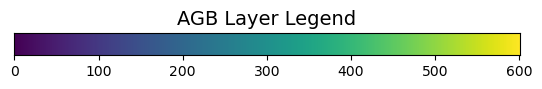

In [34]:
# AGB values range 0-600, so gradient_max = 601
plot_colormap(601, "AGB Layer Legend",'viridis')